In [211]:
import yfinance as yf 
import pandas as pd 

df = yf.download("AAPL" , start = '2016-01-01' , end = '2026-01-01')

[*********************100%***********************]  1 of 1 completed


In [212]:
df.head(5)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-01-04,23.730949,23.735456,22.976335,23.113742,270597600
2016-01-05,23.136263,23.843573,23.068686,23.821048,223164000
2016-01-06,22.683496,23.059679,22.496534,22.651960,273829600
2016-01-07,21.726149,22.555099,21.721644,22.228475,324377600
2016-01-08,21.841032,22.325337,21.795981,22.199193,283192000


In [213]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import sklearn
import tensorflow

In [214]:
df.head(2)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-01-04,23.730949,23.735456,22.976335,23.113742,270597600
2016-01-05,23.136263,23.843573,23.068686,23.821048,223164000


In [215]:
df.dropna()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-01-04,23.730949,23.735456,22.976335,23.113742,270597600
2016-01-05,23.136263,23.843573,23.068686,23.821048,223164000
2016-01-06,22.683496,23.059679,22.496534,22.651960,273829600
2016-01-07,21.726149,22.555099,21.721644,22.228475,324377600
2016-01-08,21.841032,22.325337,21.795981,22.199193,283192000
...,...,...,...,...,...
2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800


In [216]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800
2025-12-29,273.504089,274.103504,272.095404,272.435082,23715200
2025-12-30,272.824707,273.823772,272.025467,272.554970,22139600
2025-12-31,271.605835,273.424141,271.495952,272.804725,27293600


In [217]:
df.columns = df.columns.droplevel('Ticker')
df.columns.name = None

In [218]:
df.head(5)

,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,23.730949,23.735456,22.976335,23.113742,270597600
2016-01-05,23.136263,23.843573,23.068686,23.821048,223164000
2016-01-06,22.683496,23.059679,22.496534,22.651960,273829600
2016-01-07,21.726149,22.555099,21.721644,22.228475,324377600
2016-01-08,21.841032,22.325337,21.795981,22.199193,283192000


In [219]:
df = df.reset_index()

In [220]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2016-01-04,23.730949,23.735456,22.976335,23.113742,270597600
1,2016-01-05,23.136263,23.843573,23.068686,23.821048,223164000
2,2016-01-06,22.683496,23.059679,22.496534,22.651960,273829600
3,2016-01-07,21.726149,22.555099,21.721644,22.228475,324377600
4,2016-01-08,21.841032,22.325337,21.795981,22.199193,283192000


In [221]:
df['avg30'] = df['Close'].rolling(window=30).mean()

df['stn30'] = df['Close'].rolling(window=30).std()

df.tail(5)

,Date,Close,High,Low,Open,Volume,avg30,stn30
2509,2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600,274.941399,4.895673
2510,2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800,274.939068,4.896540
2511,2025-12-29,273.504089,274.103504,272.095404,272.435082,23715200,274.966042,4.885969
2512,2025-12-30,272.824707,273.823772,272.025467,272.554970,22139600,274.988354,4.874205
2513,2025-12-31,271.605835,273.424141,271.495952,272.804725,27293600,275.134884,4.695090


In [222]:
df.dropna(inplace=True)

In [223]:
from sklearn.preprocessing import MinMaxScaler

In [224]:
cs = MinMaxScaler()
close_scaled = cs.fit_transform(df[['Close']])


otf = MinMaxScaler()
all_scaled = otf.fit_transform(df.drop(['Date' , 'High', 'Low', 'Open', 'Volume'], axis = 1))

In [225]:
x = [] 
y = []
time_steps = 90
for i in range(time_steps , len(all_scaled)):
    x.append(all_scaled[i-time_steps:i])
    y.append(all_scaled[i,0])

x =np.array(x)
y=np.array(y)

In [226]:
print(x.shape)

(2395, 90, 3)


In [227]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y,train_size = 0.7 ,shuffle = False , random_state = 101)

In [228]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import LSTM, Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping 

In [229]:
model = Sequential()

In [230]:
model.add(LSTM(50, return_sequences=True , input_shape = (x_train.shape[1] , x_train.shape[2])))

c:\Users\talkw\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [231]:
model.add(Dropout(0.2))

In [232]:
model.add(LSTM(50 , return_sequences=False))

In [233]:
model.add(Dropout(0.2))

In [234]:
model.add(Dense(25))

In [235]:
model.add(Dense(1))

In [236]:
model.compile(optimizer='adam', loss = 'mean_squared_error')
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 90, 50)         │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 90, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,301 (126.18 KB)

 Trainable params: 32,301 (126.18 KB)

 Non-trainable params: 0 (0.00 B)

In [237]:
early_stop = EarlyStopping(monitor='val_loss' , patience = 10 , restore_best_weights = True)

In [ ]:
model.fit(x_train, y_train, epochs=200, batch_size=16, 
          validation_data=(x_test, y_test), callbacks=[early_stop])


Epoch 1/200


105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 0.0045 - val_loss: 0.0014
Epoch 2/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 3/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0011 - val_loss: 0.0024
Epoch 4/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 9.0114e-04 - val_loss: 0.0066
Epoch 5/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 123ms/step - loss: 7.8339e-04 - val_loss: 0.0053
Epoch 6/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 6.7118e-04 - val_loss: 0.0029
Epoch 7/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 6.0257e-04 - val_loss: 0.0018
Epoch 8/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 5.3397e-04 - val_loss: 0.0015
Epoch 9/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 5.1589e-04 - val_loss: 0.0012
Epoch 10/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 5.2086e-04 - val_loss: 0.0011
Epoch 11/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 4.5919e-04 - val_loss: 8.5801e-04
Epoc

In [239]:
predictions = model.predict(x_test)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [240]:
predictions = cs.inverse_transform(predictions)

In [241]:
y_test_actual = cs.inverse_transform(y_test.reshape(-1, 1))



In [242]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100
r2 = r2_score(y_test_actual, predictions)

print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²:   {r2:.4f}")


MAE:  $3.96
RMSE: $5.31
MAPE: 1.96%
R²:   0.9730


In [243]:
%matplotlib inline

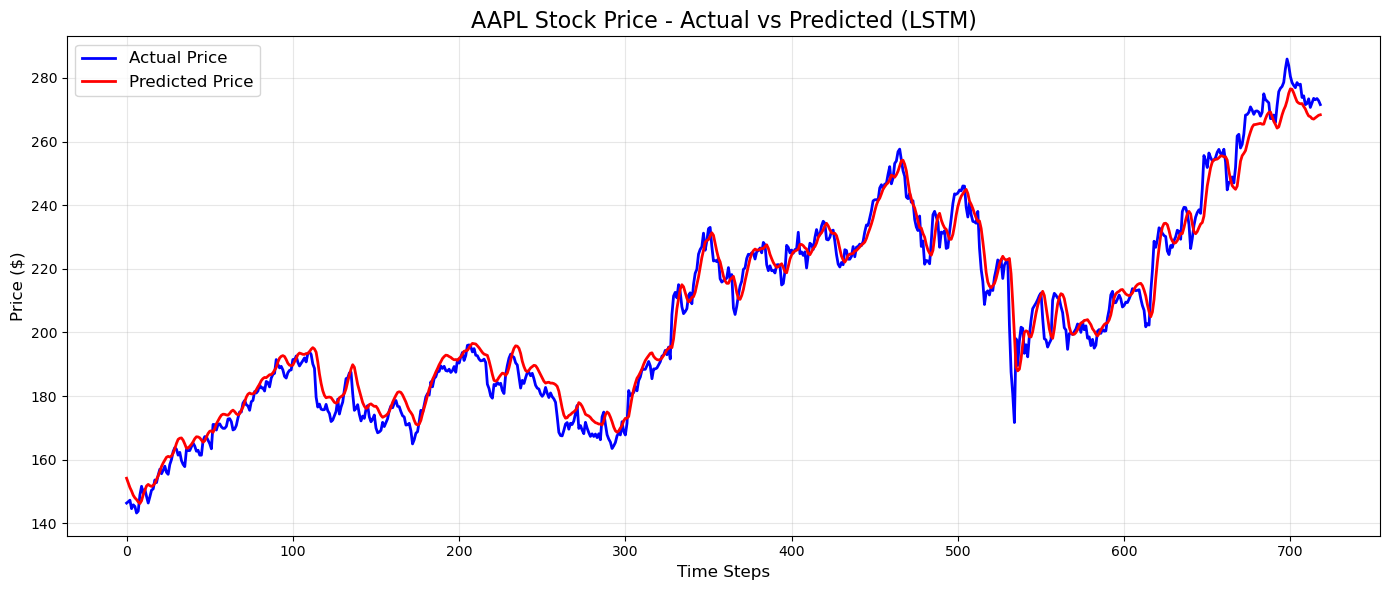

In [244]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label='Actual Price', color='blue', linewidth=2)
plt.plot(predictions, label='Predicted Price', color='red', linewidth=2)
plt.title('AAPL Stock Price - Actual vs Predicted (LSTM)', fontsize=16)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [246]:
last_90_days = all_scaled[-90:]

In [252]:
last_90_days = last_90_days.reshape(1,90,3)

predicted_sc = model.predict(last_90_days)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [253]:
predicted_sc = cs.inverse_transform(predicted_sc)

In [257]:
today_price = df['Close'].iloc[-1]


print('todays price :', today_price)
print('tommorows prediction :' , predicted_sc)

todays price : 271.6058349609375
tommorows prediction : [[268.0892]]


In [262]:
if predicted_sc[0][0] > today_price:
    print("price inscrease")
else:
    print("price decrease")

price decrease


In [270]:
model.save('lstm_stock.keras')

In [271]:
import joblib 

joblib.dump( cs , 'close_scaled.pkl')
joblib.dump(otf , 'all_scaled')

['all_scaled']